# Categorical Plots Examples

This notebook demonstrates the usage of the CategoricalPlots class methods with simple sklearn datasets.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris, load_wine
from kvbiii_plots.eda import CategoricalPlots

/home/kvbiii/Programming/Python/Paczki/kvbiii-plots/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cat_plots = CategoricalPlots()

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]
iris_df['target'] = iris.target

wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['wine_class'] = wine.target_names[wine.target]
wine_df['target'] = wine.target

print("Iris dataset shape:", iris_df.shape)
print("Wine dataset shape:", wine_df.shape)
print("\nIris species distribution:")
print(iris_df['species'].value_counts())

Iris dataset shape: (150, 6)
Wine dataset shape: (178, 15)

Iris species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 1. barplot() - Basic Bar Plot

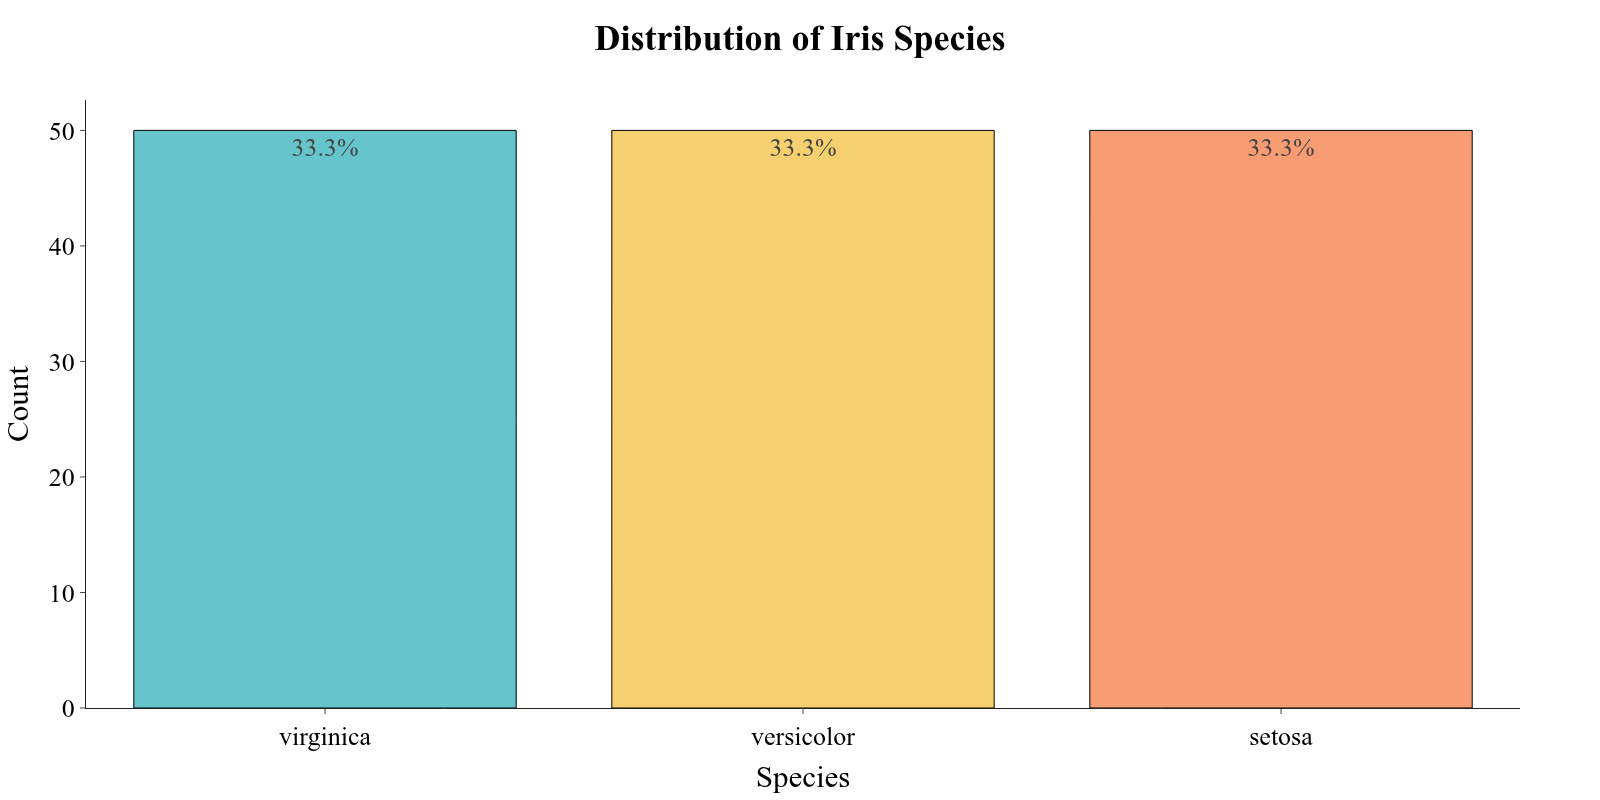

In [3]:
species_counts = iris_df['species'].value_counts()

fig = cat_plots.barplot(
    data=species_counts,
    plot_title="Distribution of Iris Species",
    width=1600,
    height=800,
    xaxis_title="Species",
    yaxis_title="Count"
)

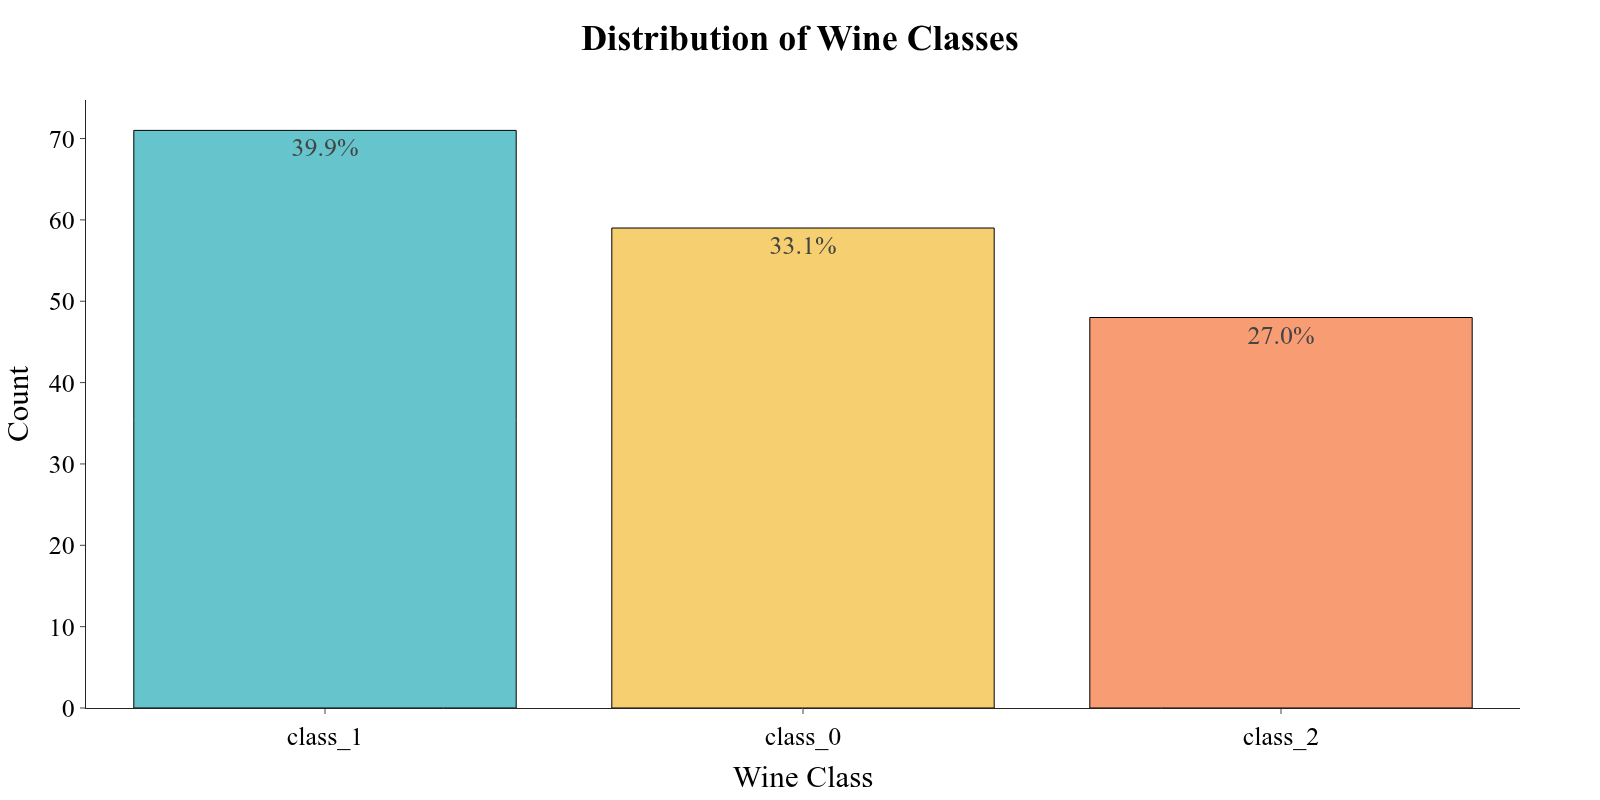

In [4]:
wine_counts = wine_df['wine_class'].value_counts()

cat_plots.barplot(
    data=wine_counts,
    plot_title="Distribution of Wine Classes",
    xaxis_title="Wine Class",
    yaxis_title="Count"
)

## 2. pie_barplot() - Combined Pie and Bar Plot

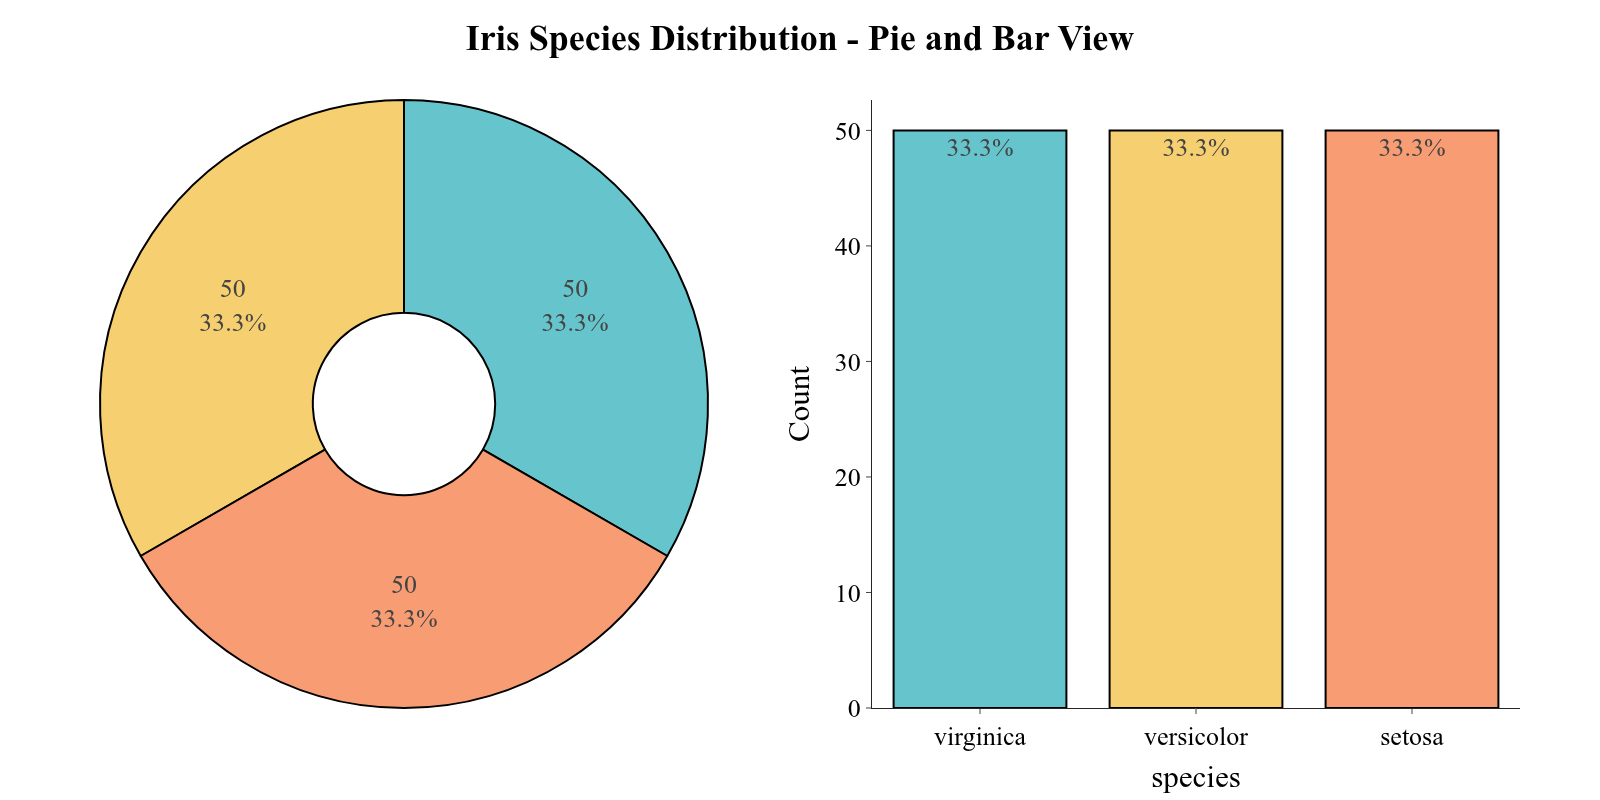

In [5]:
cat_plots.pie_barplot(
    data=iris_df,
    feature='species',
    plot_title="Iris Species Distribution - Pie and Bar View",
    width=1600,
    height=800,
)

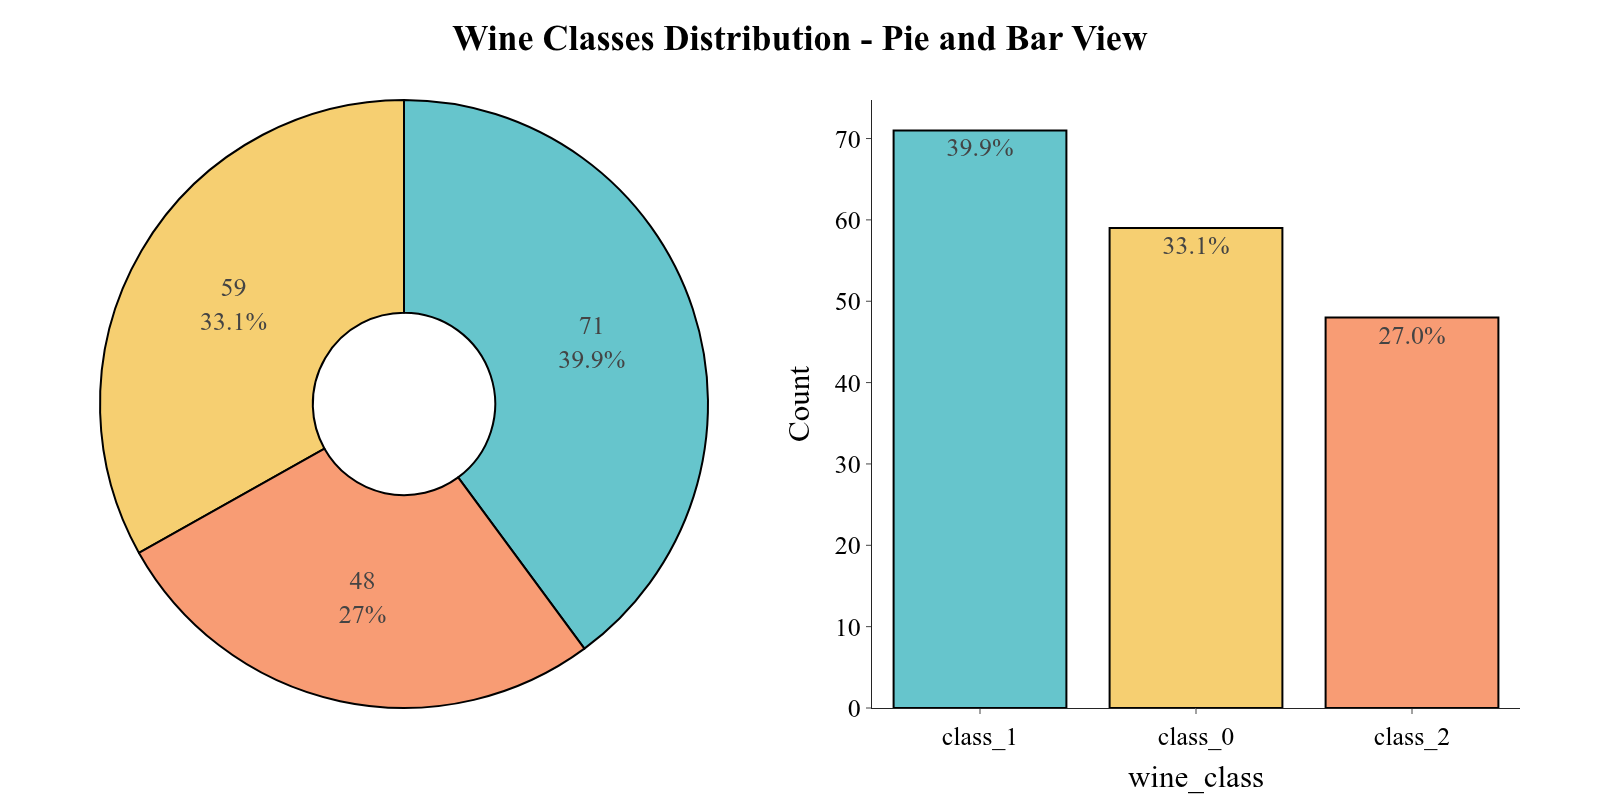

In [6]:
cat_plots.pie_barplot(
    data=wine_df,
    feature='wine_class',
    plot_title="Wine Classes Distribution - Pie and Bar View"
)

## 3. boxplot_by_categorical() - Box Plots by Category

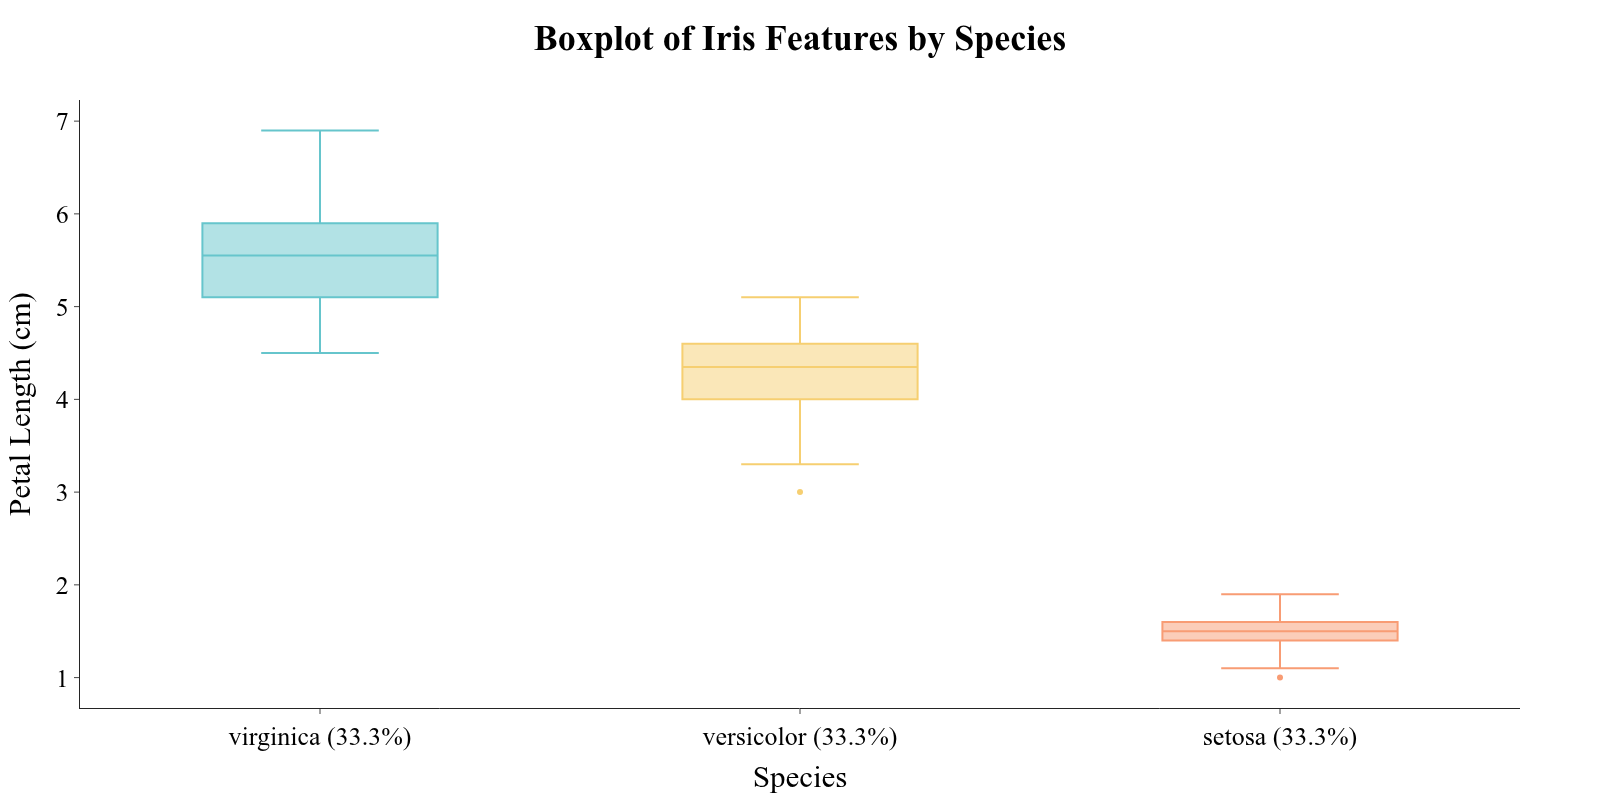

In [7]:
cat_plots.boxplot_by_categorical(
    data=iris_df,
    categorical='species',
    target='petal length (cm)',
    plot_title="Boxplot of Iris Features by Species",
    width=1600,
    height=800,
    xaxis_title="Species",
    yaxis_title="Petal Length (cm)"
)

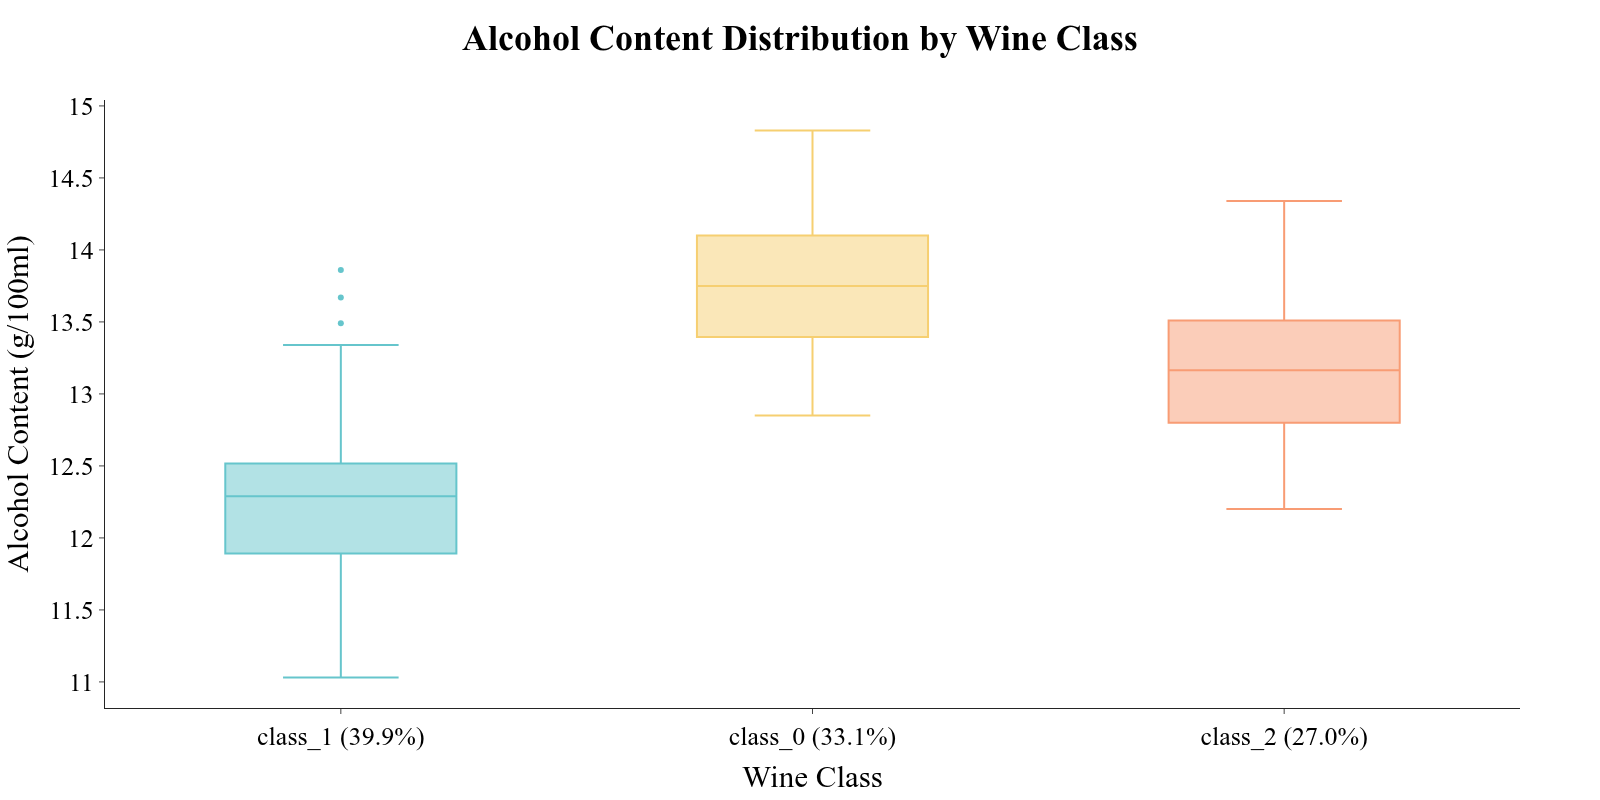

In [8]:
cat_plots.boxplot_by_categorical(
    data=wine_df,
    categorical='wine_class',
    target='alcohol',
    plot_title="Alcohol Content Distribution by Wine Class",
    width=1600,
    height=800,
    xaxis_title="Wine Class",
    yaxis_title="Alcohol Content (g/100ml)"
)

## 4. pie_boxplot_by_categorical() - Combined Pie and Box Plot

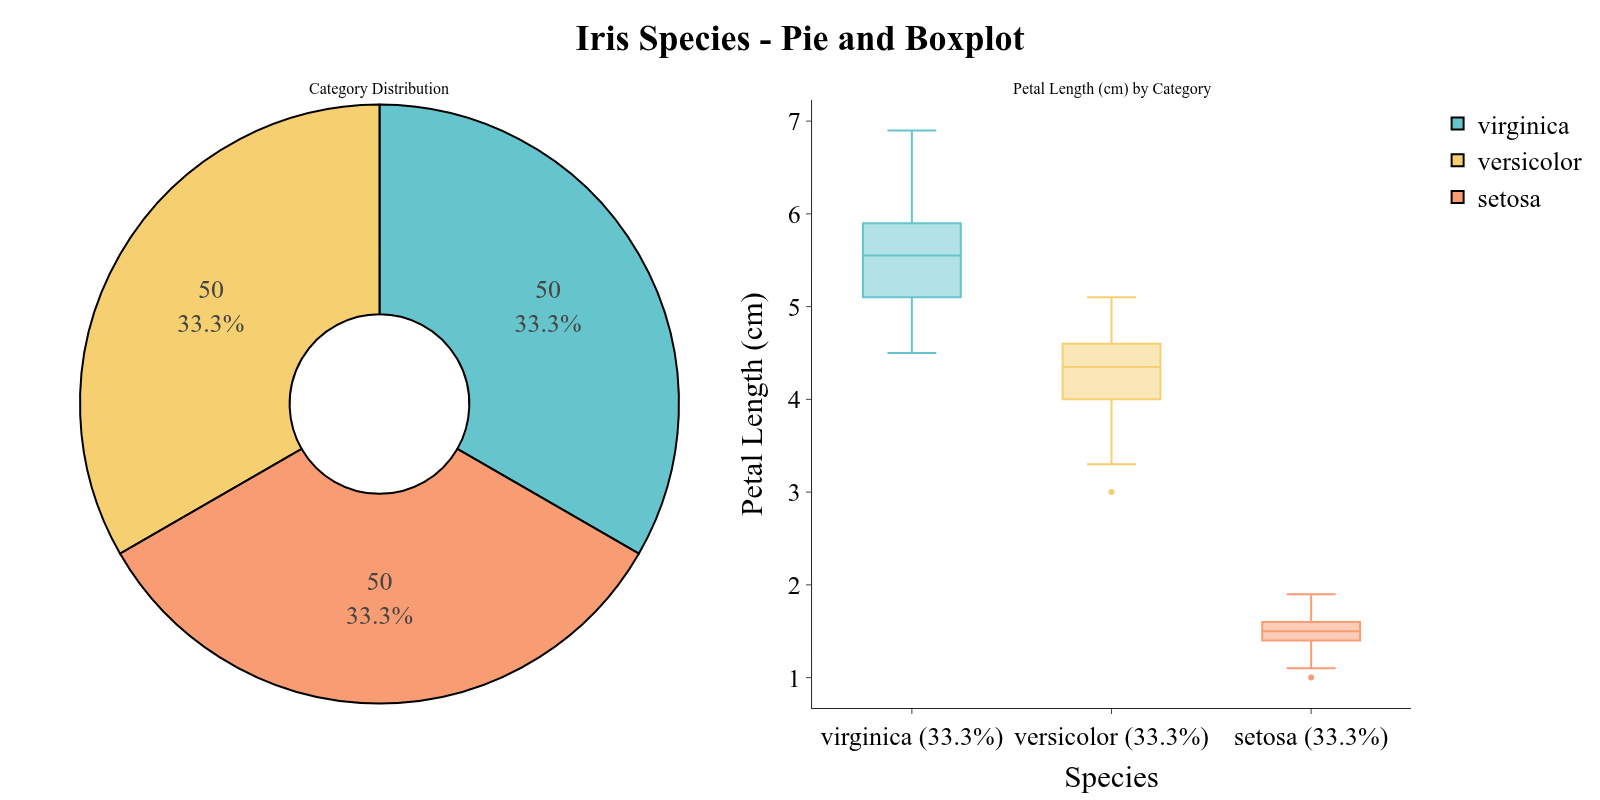

In [9]:
cat_plots.pie_boxplot_by_categorical(
    data=iris_df,
    categorical='species',
    target='petal length (cm)',
    plot_title="Iris Species - Pie and Boxplot",
    width=1600,
    height=800,
    xaxis_title="Species",
    yaxis_title="Petal Length (cm)",
    hole_size=0.3
)

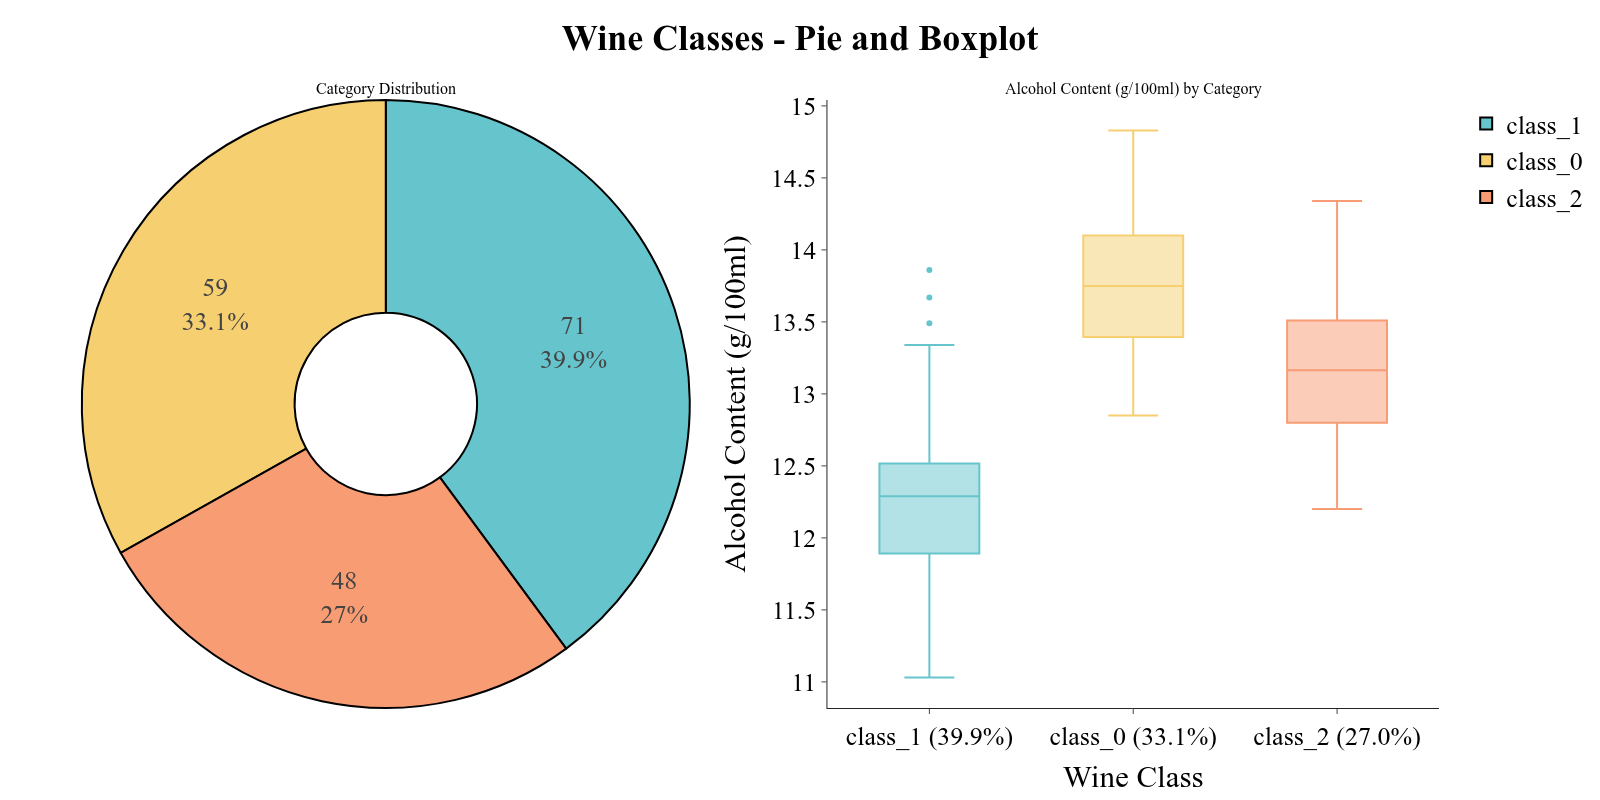

In [10]:
cat_plots.pie_boxplot_by_categorical(
    data=wine_df,
    categorical='wine_class',
    target='alcohol',
    plot_title="Wine Classes - Pie and Boxplot",
    width=1600,
    height=800,
    xaxis_title="Wine Class",
    yaxis_title="Alcohol Content (g/100ml)",
    hole_size=0.3
)

## 5. pie_stacked_barplot_by_hue() - Stacked Bar Plot with Pie Chart

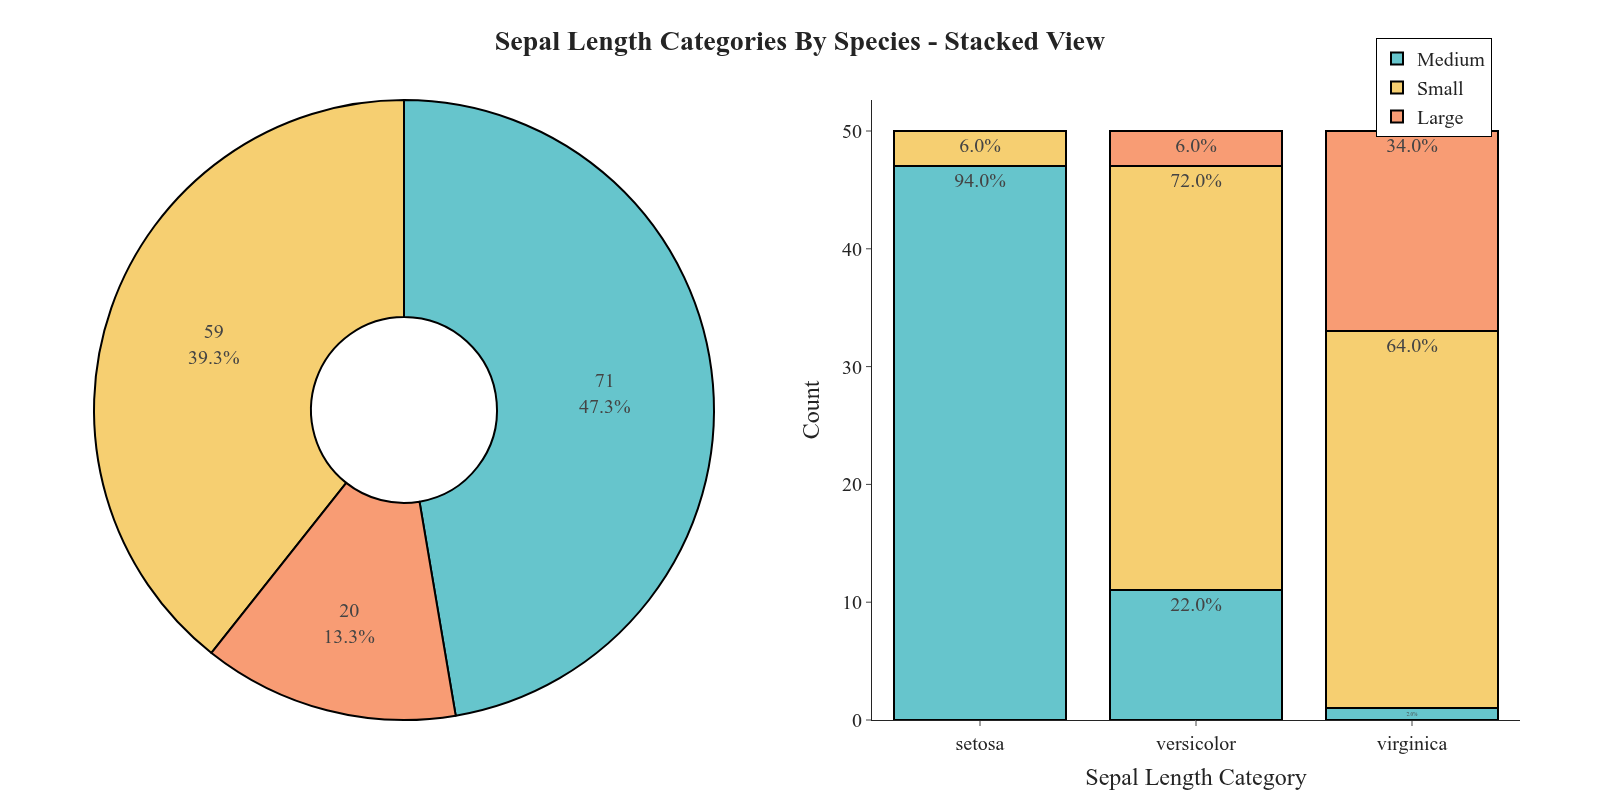

In [11]:
iris_df_binned = iris_df.copy()
iris_df_binned['sepal_length_bin'] = pd.cut(
    iris_df_binned['sepal length (cm)'], 
    bins=3, 
    labels=['Small', 'Medium', 'Large']
)

cat_plots.pie_stacked_barplot_by_hue(
    data=iris_df_binned,
    feature='sepal_length_bin',
    hue='species',
    plot_title="Sepal Length Categories by Species - Stacked View",
    width=1600,
    height=800,
    xaxis_title="Sepal Length Category",
    yaxis_title="Count",
    hole_size=0.3
)

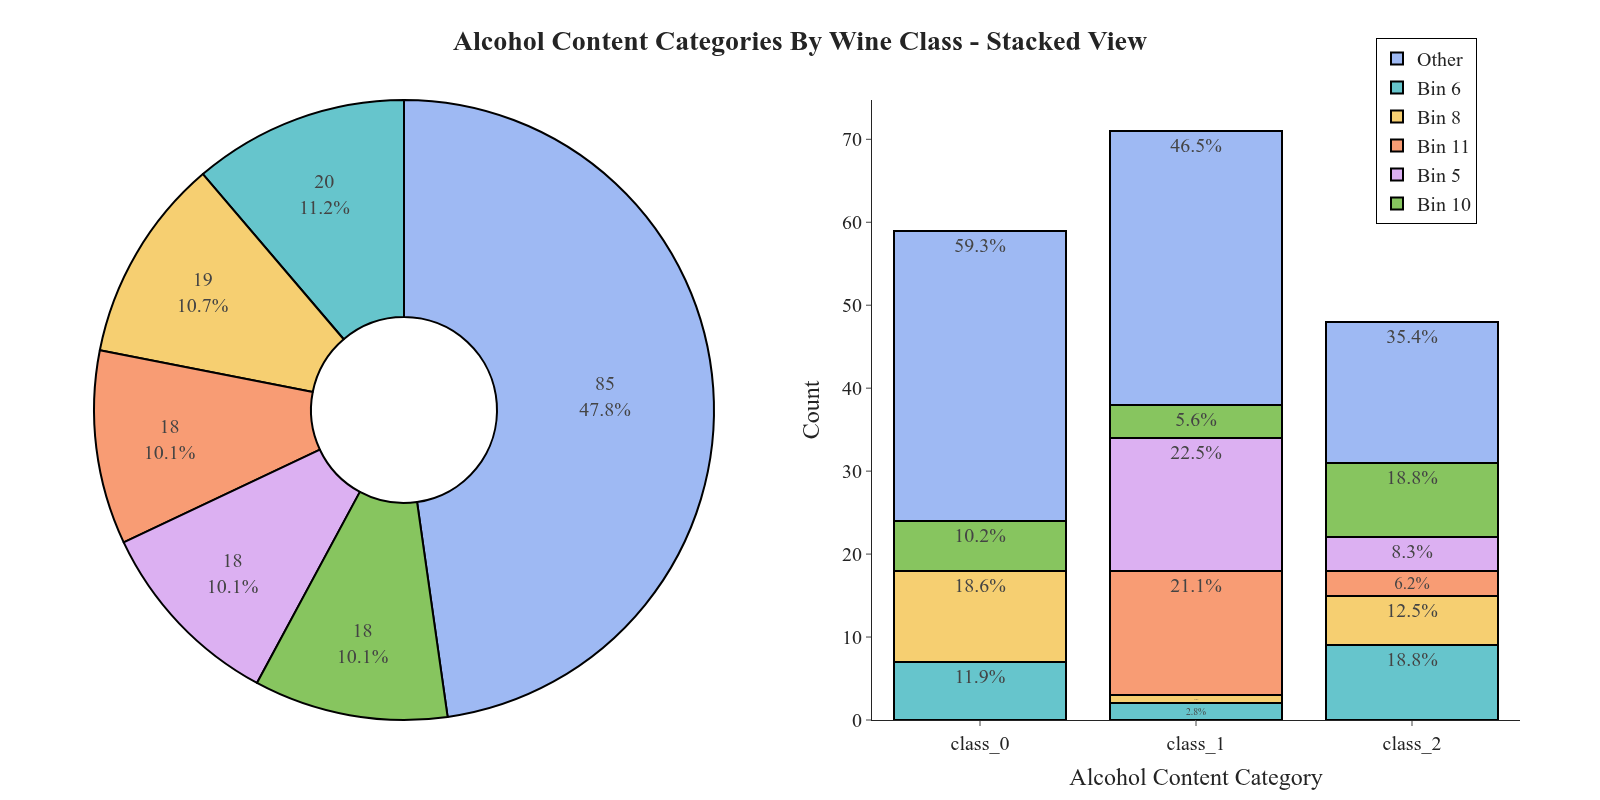

In [12]:
wine_df_binned = wine_df.copy()
wine_df_binned["alcohol_bin"] = pd.cut(
    wine_df_binned["alcohol"], bins=15, labels=[f"Bin {i+1}" for i in range(15)]
)

cat_plots.pie_stacked_barplot_by_hue(
    data=wine_df_binned,
    feature="alcohol_bin",
    hue="wine_class",
    top_n=5,
    plot_title="Alcohol Content Categories by Wine Class - Stacked View",
    width=1600,
    height=800,
    xaxis_title="Alcohol Content Category",
    yaxis_title="Count",
    hole_size=0.3,
)